# Visualize SAM3 + DAP3 Test Output

This notebook visualizes processed detection frames from one video output directory.

It currently includes:
- RGB frame with segmentation overlay
- Depth map with colorbar
- Paginated rendering (subset of frames at a time)

Update the config cell first (especially `VIDEO_PATH`) before running.


In [1]:
import json
import math
from pathlib import Path

try:
    import cv2
except ImportError as e:
    raise ImportError('OpenCV is required: pip install opencv-python') from e

try:
    import numpy as np
except ImportError as e:
    raise ImportError('NumPy is required: pip install numpy') from e

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
except ImportError as e:
    raise ImportError('matplotlib is required: pip install matplotlib') from e


In [16]:
%cd /home/dl18206/projs/Unmarked-Anything

/home/dl18206/projs/Unmarked-Anything


In [17]:
# Required inputs
OUTPUT_ROOT = Path('outputs/demo')
VIDEO_STEM = '03290392_0_10'  # Set to None to auto-select first successful video from run_manifest.json
VIDEO_PATH = Path('assets/videos/03290392_0_10.MP4')

# Display settings
PAGE_SIZE = 2
OVERLAY_ALPHA = 0.45
DEPTH_CMAP = 'inferno'
SHOW_BBOX_AND_CENTER = True

# Manual pagination fallback
MANUAL_PAGE = 5

In [18]:
def load_artifacts(output_root: Path, video_stem: str | None) -> tuple[dict, np.lib.npyio.NpzFile]:
    manifest_path = output_root / 'run_manifest.json'
    manifest = None
    if manifest_path.is_file():
        manifest = json.loads(manifest_path.read_text())

    selected_stem = video_stem
    if selected_stem is None:
        if not manifest:
            raise FileNotFoundError(
                f'VIDEO_STEM is None and manifest not found: {manifest_path}'
            )
        successes = [v for v in manifest.get('videos', []) if v.get('status') == 'success']
        if not successes:
            raise RuntimeError('No successful videos found in run_manifest.json')
        selected_stem = successes[0]['video_name']

    video_dir = output_root / selected_stem
    json_path = video_dir / f'{selected_stem}.json'
    npz_path = video_dir / f'{selected_stem}_arrays.npz'

    if not json_path.is_file():
        raise FileNotFoundError(f'Missing JSON output: {json_path}')
    if not npz_path.is_file():
        raise FileNotFoundError(f'Missing NPZ output: {npz_path}')

    video_json = json.loads(json_path.read_text())
    npz_data = np.load(npz_path, allow_pickle=False)

    frames = video_json.get('frames', [])
    processed_count = sum(1 for f in frames if f.get('status') == 'processed')

    print(f'Loaded video: {selected_stem}')
    print(f'  JSON status: {video_json.get("status")} | SAM mode: {video_json.get("sam3_mode")}')
    print(f'  Frames total: {len(frames)} | Processed detections: {processed_count}')
    print(f'  NPZ members: {len(npz_data.files)}')

    if manifest is not None:
        summary = manifest.get('summary', {})
        print('  Manifest summary:', summary)

    return video_json, npz_data


video_json, npz_data = load_artifacts(OUTPUT_ROOT, VIDEO_STEM)


Loaded video: 03290392_0_10
  JSON status: success | SAM mode: track
  Frames total: 242 | Processed detections: 143
  NPZ members: 429
  Manifest summary: {'processed_videos': 1, 'failed_videos': 0, 'skipped_videos': 0, 'sampled_frames': 242, 'processed_frames': 143, 'empty_mask_frames': 99, 'error_frames': 0}


In [19]:
def select_detected_frames(video_json: dict) -> list[dict]:
    frames = video_json.get('frames', [])
    processed = [f for f in frames if f.get('status') == 'processed']
    processed.sort(key=lambda f: int(f.get('frame_index', -1)))

    validated = []
    missing_rows = 0
    for f in processed:
        npz_keys = f.get('npz_keys') or {}
        if not npz_keys.get('depth') or not npz_keys.get('masks'):
            missing_rows += 1
            continue
        validated.append(f)

    if missing_rows:
        print(f'Warning: skipped {missing_rows} processed rows with missing npz_keys references.')

    if not validated:
        raise RuntimeError('No valid processed detection frames found in JSON output.')

    print(f'Validated processed frames: {len(validated)}')
    return validated


processed_records = select_detected_frames(video_json)
NUM_PAGES = math.ceil(len(processed_records) / PAGE_SIZE)
print(f'Pages: {NUM_PAGES} (PAGE_SIZE={PAGE_SIZE})')

Validated processed frames: 143
Pages: 72 (PAGE_SIZE=2)


In [20]:
if str(VIDEO_PATH).startswith('/absolute/or/local/path'):
    raise FileNotFoundError(
        'Please set VIDEO_PATH in the config cell to a local source video path before continuing.'
    )
if not VIDEO_PATH.is_file():
    raise FileNotFoundError(f'Video path not found: {VIDEO_PATH}')

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f'Failed to open video: {VIDEO_PATH}')


def read_video_frame(cap: cv2.VideoCapture, frame_index: int) -> np.ndarray:
    ok = cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    if not ok:
        raise RuntimeError(f'Failed to seek to frame {frame_index}')
    ret, frame_bgr = cap.read()
    if not ret or frame_bgr is None:
        raise RuntimeError(f'Failed to decode frame {frame_index}')
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


print(f'Opened source video: {VIDEO_PATH}')


Opened source video: assets/videos/03290392_0_10.MP4


In [21]:
def build_union_mask(npz_data, frame_row: dict) -> np.ndarray:
    npz_keys = frame_row.get('npz_keys') or {}
    mask_entries = npz_keys.get('masks') or []
    if not mask_entries:
        raise KeyError(f'Frame {frame_row.get("frame_index")}: no mask entries in npz_keys')

    union_mask = None
    missing_keys = []

    for entry in mask_entries:
        key = entry.get('key')
        if not key:
            continue
        if key not in npz_data:
            missing_keys.append(key)
            continue
        mask_arr = np.asarray(npz_data[key])
        mask_bool = mask_arr.astype(bool)
        if union_mask is None:
            union_mask = mask_bool.copy()
        else:
            if union_mask.shape != mask_bool.shape:
                raise ValueError(
                    f'Frame {frame_row.get("frame_index")}: mask shape mismatch {union_mask.shape} vs {mask_bool.shape}'
                )
            union_mask |= mask_bool

    if union_mask is None:
        raise KeyError(
            f'Frame {frame_row.get("frame_index")}: no valid mask arrays found. Missing keys: {missing_keys}'
        )

    return union_mask


In [22]:
def render_page(
    records: list[dict],
    page: int = 0,
    page_size: int = PAGE_SIZE,
    cap_obj: cv2.VideoCapture = cap,
    npz_obj = npz_data,
    overlay_alpha: float = OVERLAY_ALPHA,
    depth_cmap: str = DEPTH_CMAP,
) -> None:
    if page_size <= 0:
        raise ValueError('page_size must be > 0')
    total = len(records)
    if total == 0:
        raise RuntimeError('No records to render.')

    max_page = max(0, math.ceil(total / page_size) - 1)
    if page < 0 or page > max_page:
        raise ValueError(f'page out of range: {page}. valid range is 0..{max_page}')

    start = page * page_size
    end = min(start + page_size, total)
    page_records = records[start:end]

    n = len(page_records)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(16, max(4 * n, 5)))
    if n == 1:
        axes = np.array([axes])

    warnings = []

    for i, rec in enumerate(page_records):
        ax_overlay, ax_depth = axes[i, 0], axes[i, 1]
        frame_idx = int(rec.get('frame_index'))

        # Read source frame
        try:
            frame_rgb = read_video_frame(cap_obj, frame_idx)
        except Exception as e:
            warnings.append(f'Frame {frame_idx}: decode failed ({e})')
            ax_overlay.text(0.5, 0.5, f'Decode failed\nframe={frame_idx}', ha='center', va='center')
            ax_overlay.axis('off')
            ax_depth.axis('off')
            continue

        # Build union mask
        try:
            union_mask = build_union_mask(npz_obj, rec)
        except Exception as e:
            warnings.append(f'Frame {frame_idx}: mask missing/invalid ({e})')
            union_mask = np.zeros(frame_rgb.shape[:2], dtype=bool)

        if union_mask.shape != frame_rgb.shape[:2]:
            warnings.append(
                f'Frame {frame_idx}: mask/frame shape mismatch {union_mask.shape} vs {frame_rgb.shape[:2]} (mask ignored)'
            )
            union_mask = np.zeros(frame_rgb.shape[:2], dtype=bool)

        # Overlay view
        overlay = frame_rgb.astype(np.float32) / 255.0
        overlay_color = np.array([0.0, 1.0, 1.0], dtype=np.float32)
        if np.any(union_mask):
            overlay[union_mask] = (1.0 - overlay_alpha) * overlay[union_mask] + overlay_alpha * overlay_color

        ax_overlay.imshow(overlay)
        if SHOW_BBOX_AND_CENTER:
            bbox = rec.get('bbox_xyxy')
            if bbox and len(bbox) == 4:
                x1, y1, x2, y2 = bbox
                ax_overlay.add_patch(
                    Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='lime', linewidth=1.5)
                )
            center = rec.get('center_xy')
            if center and len(center) == 2:
                ax_overlay.plot(center[0], center[1], marker='o', markersize=5, color='yellow', markeredgecolor='black')

        ts = rec.get('timestamp_sec')
        ts_txt = f'{ts:.2f}s' if isinstance(ts, (int, float)) else 'n/a'
        ax_overlay.set_title(
            f'Frame {frame_idx} @ {ts_txt} | mask_px={rec.get("mask_nonzero_pixels", 0)} ' \
            f'| area={rec.get("mask_area_fraction", 0.0):.4f}'
        )
        ax_overlay.axis('off')

        # Depth view
        depth_key = ((rec.get('npz_keys') or {}).get('depth'))
        if not depth_key or depth_key not in npz_obj:
            warnings.append(f'Frame {frame_idx}: missing depth key {depth_key}')
            ax_depth.text(0.5, 0.5, f'Missing depth\n{depth_key}', ha='center', va='center')
            ax_depth.axis('off')
            continue

        depth = np.asarray(npz_obj[depth_key], dtype=np.float32)
        im = ax_depth.imshow(depth, cmap=depth_cmap)
        plt.colorbar(im, ax=ax_depth, fraction=0.046, pad=0.01)
        ax_depth.set_title(
            f'Depth | mean(mask)={rec.get("depth_mask_mean")} | center={rec.get("depth_center_value")}'
        )
        ax_depth.axis('off')

    fig.suptitle(f'Processed detections: page {page + 1}/{max_page + 1} (frames {start}..{end - 1})', y=1.002)
    plt.tight_layout()
    plt.show()

    if warnings:
        print('Warnings:')
        for w in warnings[:30]:
            print('-', w)
        if len(warnings) > 30:
            print(f'... {len(warnings) - 30} more warnings')


In [23]:
# Optional interactive pagination (requires ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display

    max_page = max(0, math.ceil(len(processed_records) / PAGE_SIZE) - 1)
    page_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=max_page,
        step=1,
        description='Page',
        continuous_update=False,
    )

    def _render_from_slider(page: int):
        render_page(processed_records, page=page, page_size=PAGE_SIZE)

    out = widgets.interactive_output(_render_from_slider, {'page': page_slider})
    display(page_slider, out)
except Exception as e:
    print('ipywidgets unavailable. Use manual pagination instead:')
    print('  render_page(processed_records, page=<k>, page_size=PAGE_SIZE)')
    print(f'Widget reason: {e}')


IntSlider(value=0, continuous_update=False, description='Page', max=71)

Output()

=== DAP3-style depth statistics (mask vs bbox) ===
frame=24: bbox=(171,104,342,265) | center=(256,184) | mask_px=14662 | bbox_px=27864 | mask_mean=2.822233 | bbox_mean=3.038582 | center_depth=5.076344 | bbox_only_mean=3.278856
frame=48: bbox=(263,115,465,328) | center=(364,221) | mask_px=21264 | bbox_px=43442 | mask_mean=2.485310 | bbox_mean=3.082202 | center_depth=2.480943 | bbox_only_mean=3.654494
frame=72: bbox=(381,127,603,358) | center=(492,242) | mask_px=26253 | bbox_px=51736 | mask_mean=2.446394 | bbox_mean=3.005800 | center_depth=4.384603 | bbox_only_mean=3.582109


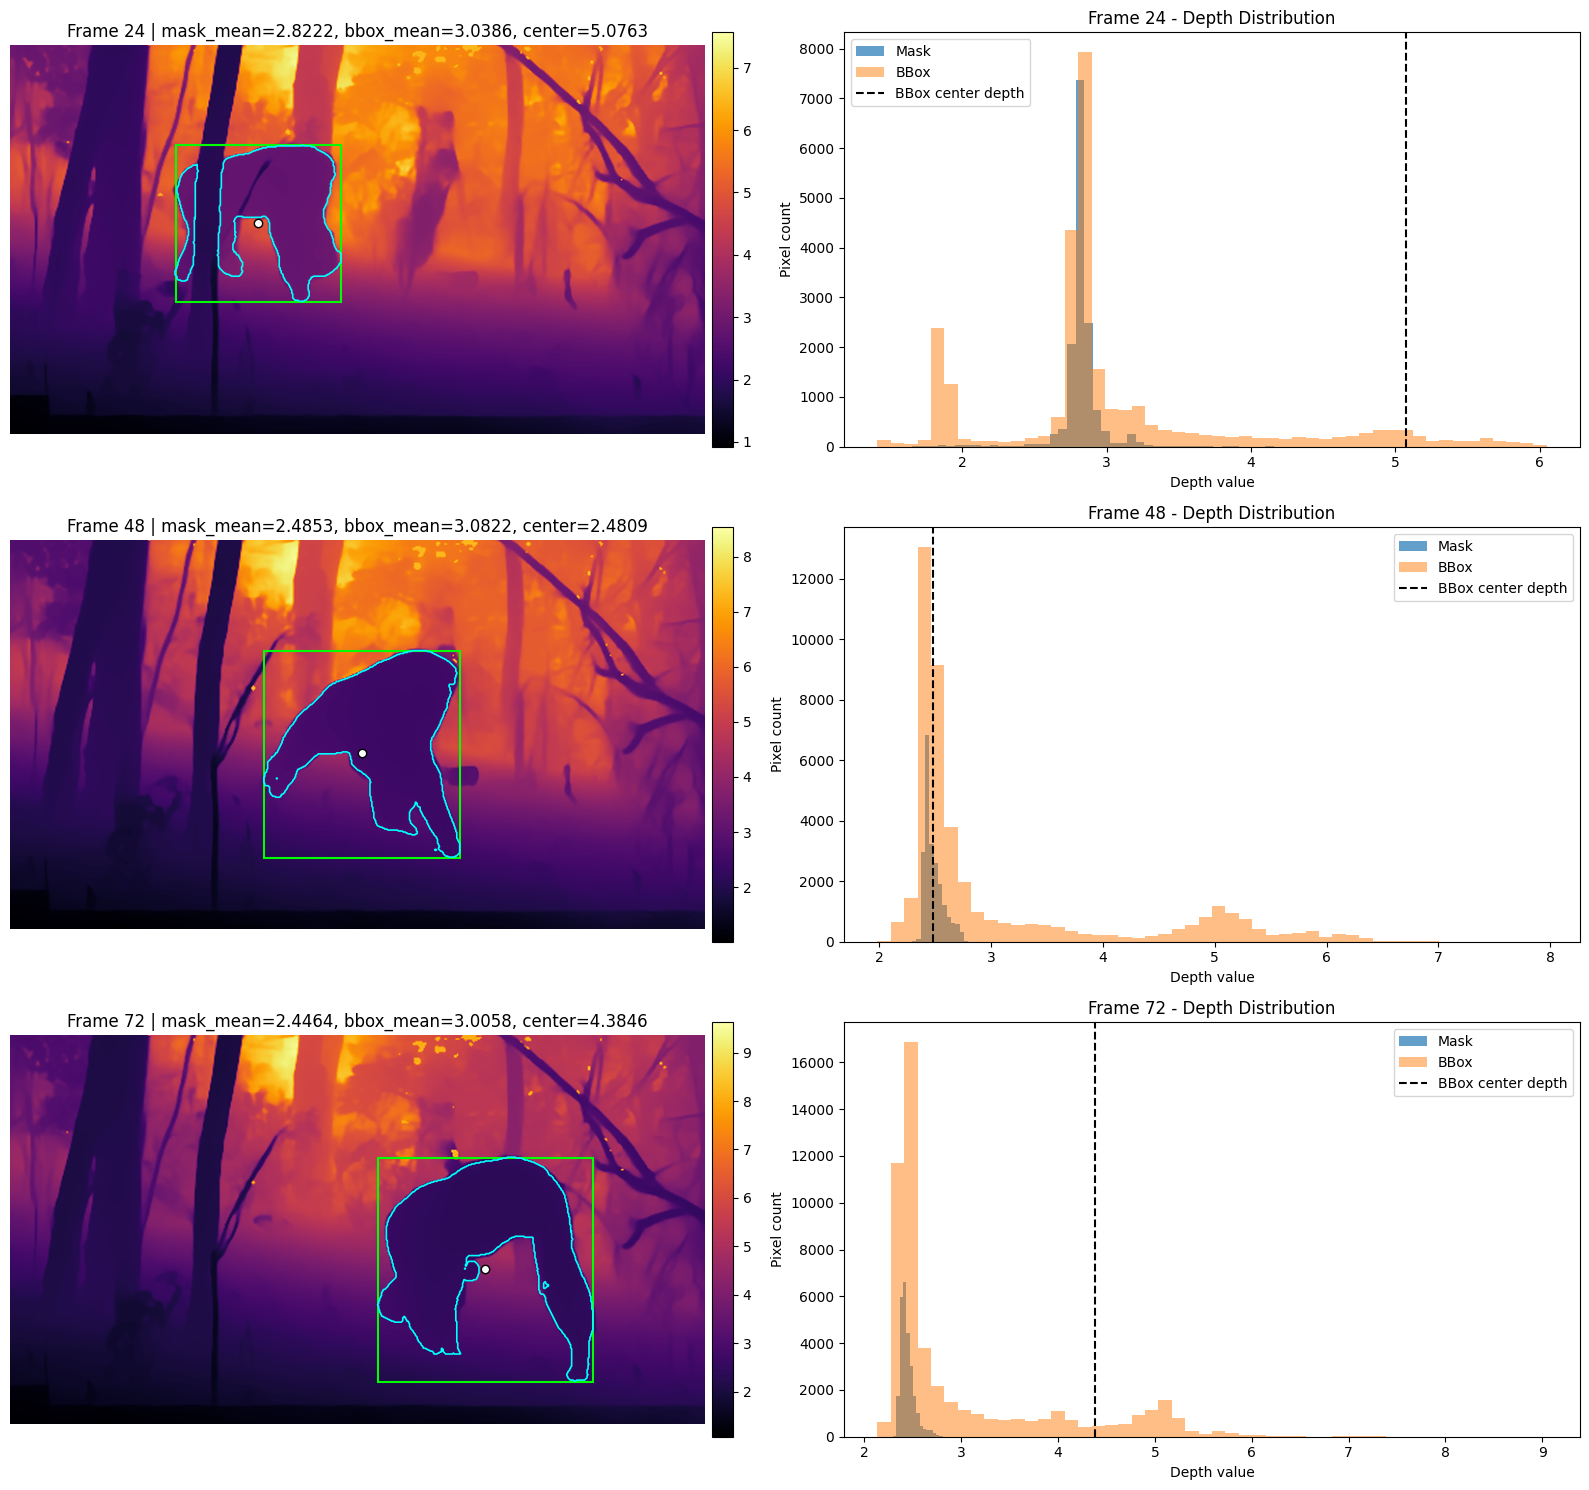

In [24]:
# DAP3-style selected-frame comparative analysis (depth + mask/bbox stats)
import matplotlib.patches as patches

# User configuration:
# - mode='manual': use MANUAL_FRAME_INDICES from original video frame indices
# - mode='auto': evenly sample AUTO_SELECT_COUNT processed frames
ANALYSIS_MODE = 'manual'  # 'manual' or 'auto'
MANUAL_FRAME_INDICES = [
    24,
    48,
    72
    # int(processed_records[0]['frame_index']) if processed_records else 0,
    # int(processed_records[len(processed_records)//2]['frame_index']) if processed_records else 0,
    # int(processed_records[-1]['frame_index']) if processed_records else 0,
]
AUTO_SELECT_COUNT = 3


def _select_records_for_analysis(records, mode='manual', manual_frame_indices=None, auto_count=3):
    if not records:
        raise RuntimeError('No processed records available for analysis.')

    manual_frame_indices = manual_frame_indices or []
    rec_by_idx = {int(r.get('frame_index')): r for r in records}

    if mode == 'manual':
        selected = []
        missing = []
        seen = set()
        for idx in manual_frame_indices:
            idx = int(idx)
            if idx in seen:
                continue
            seen.add(idx)
            rec = rec_by_idx.get(idx)
            if rec is None:
                missing.append(idx)
            else:
                selected.append(rec)
        if missing:
            print(f'Warning: frame indices not found in processed detections: {missing}')
        if not selected:
            raise RuntimeError('Manual mode selected but no valid frame indices were found.')
        selected.sort(key=lambda r: int(r.get('frame_index', -1)))
        return selected

    # auto mode: evenly sample from processed records
    n = len(records)
    count = max(1, min(int(auto_count), n))
    if count == 1:
        picks = [0]
    else:
        picks = sorted(set(round(i * (n - 1) / (count - 1)) for i in range(count)))
    return [records[i] for i in picks]


analysis_records = _select_records_for_analysis(
    processed_records,
    mode=ANALYSIS_MODE,
    manual_frame_indices=MANUAL_FRAME_INDICES,
    auto_count=AUTO_SELECT_COUNT,
)

results = []
for rec in analysis_records:
    frame_idx = int(rec.get('frame_index'))

    frame_rgb = read_video_frame(cap, frame_idx)
    union_mask = build_union_mask(npz_data, rec).astype(bool)

    if union_mask.shape != frame_rgb.shape[:2]:
        raise RuntimeError(
            f'Frame {frame_idx}: mask/frame shape mismatch {union_mask.shape} vs {frame_rgb.shape[:2]}'
        )

    depth_key = ((rec.get('npz_keys') or {}).get('depth'))
    if not depth_key or depth_key not in npz_data:
        raise KeyError(f'Frame {frame_idx}: missing depth key {depth_key}')

    depth = np.asarray(npz_data[depth_key], dtype=np.float32)
    if depth.shape != frame_rgb.shape[:2]:
        depth = cv2.resize(depth, (frame_rgb.shape[1], frame_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)

    # Prefer bbox/center from JSON record; otherwise derive from mask
    bbox = rec.get('bbox_xyxy')
    center = rec.get('center_xy')

    if (not bbox or len(bbox) != 4) and np.any(union_mask):
        ys, xs = np.where(union_mask)
        bbox = [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]

    if (not center or len(center) != 2) and bbox and len(bbox) == 4:
        x1, y1, x2, y2 = [int(v) for v in bbox]
        center = [int((x1 + x2) // 2), int((y1 + y2) // 2)]

    if not bbox or len(bbox) != 4:
        raise RuntimeError(f'Frame {frame_idx}: no bbox available and mask is empty.')

    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, min(x1, depth.shape[1] - 1))
    x2 = max(0, min(x2, depth.shape[1] - 1))
    y1 = max(0, min(y1, depth.shape[0] - 1))
    y2 = max(0, min(y2, depth.shape[0] - 1))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1

    bbox_mask = np.zeros_like(union_mask, dtype=bool)
    bbox_mask[y1:y2 + 1, x1:x2 + 1] = True

    if not center or len(center) != 2:
        cx, cy = int((x1 + x2) // 2), int((y1 + y2) // 2)
    else:
        cx, cy = [int(v) for v in center]
    cx = max(0, min(cx, depth.shape[1] - 1))
    cy = max(0, min(cy, depth.shape[0] - 1))

    mask_vals = depth[union_mask]
    bbox_vals = depth[bbox_mask]
    bbox_only_vals = depth[bbox_mask & (~union_mask)]
    center_depth = float(depth[cy, cx])

    result = {
        'frame_idx': frame_idx,
        'depth': depth,
        'mask': union_mask,
        'bbox': (x1, y1, x2, y2),
        'bbox_mask': bbox_mask,
        'center': (cx, cy),
        'center_depth': center_depth,
        'mask_pixels': int(union_mask.sum()),
        'bbox_pixels': int(bbox_mask.sum()),
        'mask_mean': float(np.nanmean(mask_vals)) if mask_vals.size else float('nan'),
        'bbox_mean': float(np.nanmean(bbox_vals)) if bbox_vals.size else float('nan'),
        'bbox_only_mean': float(np.nanmean(bbox_only_vals)) if bbox_only_vals.size else float('nan'),
    }
    results.append(result)

if not results:
    raise RuntimeError('No analysis results generated.')

print('=== DAP3-style depth statistics (mask vs bbox) ===')
for r in results:
    x1, y1, x2, y2 = r['bbox']
    cx, cy = r['center']
    bbox_only_txt = 'NaN' if np.isnan(r['bbox_only_mean']) else f"{r['bbox_only_mean']:.6f}"
    print(
        f"frame={r['frame_idx']}: bbox=({x1},{y1},{x2},{y2}) | center=({cx},{cy}) | "
        f"mask_px={r['mask_pixels']} | bbox_px={r['bbox_pixels']} | "
        f"mask_mean={r['mask_mean']:.6f} | bbox_mean={r['bbox_mean']:.6f} | "
        f"center_depth={r['center_depth']:.6f} | bbox_only_mean={bbox_only_txt}"
    )

# Plot: left = depth map + segmentation contour + bbox + center, right = distributions
n = len(results)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(16, max(4, 5 * n)), squeeze=False)

for i, r in enumerate(results):
    ax_depth = axes[i, 0]
    ax_dist = axes[i, 1]

    x1, y1, x2, y2 = r['bbox']
    cx, cy = r['center']

    im = ax_depth.imshow(r['depth'], cmap=DEPTH_CMAP)
    ax_depth.contour(r['mask'].astype(np.uint8), levels=[0.5], colors=['cyan'], linewidths=1.2)
    rect = patches.Rectangle((x1, y1), x2 - x1 + 1, y2 - y1 + 1, fill=False, edgecolor='lime', linewidth=1.5)
    ax_depth.add_patch(rect)
    ax_depth.plot(cx, cy, marker='o', markersize=6, color='white', markeredgecolor='black')

    ax_depth.set_title(
        f"Frame {r['frame_idx']} | mask_mean={r['mask_mean']:.4f}, "
        f"bbox_mean={r['bbox_mean']:.4f}, center={r['center_depth']:.4f}"
    )
    ax_depth.axis('off')
    plt.colorbar(im, ax=ax_depth, fraction=0.046, pad=0.01)

    mask_vals = r['depth'][r['mask']]
    bbox_vals = r['depth'][r['bbox_mask']]
    ax_dist.hist(mask_vals[np.isfinite(mask_vals)], bins=50, alpha=0.7, label='Mask')
    ax_dist.hist(bbox_vals[np.isfinite(bbox_vals)], bins=50, alpha=0.5, label='BBox')
    ax_dist.axvline(r['center_depth'], color='black', linestyle='--', linewidth=1.5, label='BBox center depth')
    ax_dist.set_title(f"Frame {r['frame_idx']} - Depth Distribution")
    ax_dist.set_xlabel('Depth value')
    ax_dist.set_ylabel('Pixel count')
    ax_dist.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Cleanup
def close_video() -> None:
    try:
        cap.release()
        print('Video handle released.')
    except NameError:
        print('No active video handle.')

close_video()